In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine , load_digits

In [3]:
wine = load_wine(as_frame=True)
X_wine = wine.data
Y_wine = wine.target
print("Features : ",X_wine.columns.to_list())
print("Classes : ",wine.target_names)

Features :  ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes :  ['class_0' 'class_1' 'class_2']


In [4]:
X_wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [5]:
Y_wine

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

In [8]:
X_wine.describe().loc[["min","max"]]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
min,11.03,0.74,1.36,10.6,70.0,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.0
max,14.83,5.80,3.23,30.0,162.0,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.0


In [9]:
X_wine_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [10]:
def pca_from_scratch(X,n_components):
    cov_mat = np.cov(X.T)
    eigenvalues , eigenvector = np.linalg.eigh(cov_mat)
    sorted_idx = np.argsort(eigenvalues[::-1])
    eigenvalues_sorted = eigenvalues[sorted_idx]
    print(eigenvalues.shape)
    print(eigenvector.shape)
    eigenvector_sorted = eigenvector[:,sorted_idx]
    total_variance = np.sum(eigenvalues_sorted)
    variance_ratio = eigenvalues_sorted/total_variance
    top_k_eigenvectors = eigenvector_sorted[:,:n_components]
    print(top_k_eigenvectors.shape)
    print(X.shape)
    X_projected = X @ top_k_eigenvectors
    print(X_projected.shape)
    return total_variance,top_k_eigenvectors,X_projected,eigenvalues_sorted,variance_ratio

total_variance,top_k_eigenvectors,X_projected,eigenvalues_sorted,variance_ratio =pca_from_scratch(X_wine_scaled,2)
    

(13,)
(13, 13)
(13, 2)
(178, 13)
(178, 2)


In [11]:
from sklearn.decomposition import PCA
sklearn_pca = PCA(n_components=2)
X_pca_sklearn = sklearn_pca.fit_transform(X_wine_scaled)
print("Sklearn explained variance ratio:", sklearn_pca.explained_variance_ratio_.round(4))
print("Scratch explained variance ratio:", variance_ratio[:2].round(4))
print("\n(These should match almost exactly)")
 
print("\nFirst 5 rows - Scratch PCA projection:")
print(X_projected[:5].round(3))
print("\nFirst 5 rows - Sklearn PCA projection:")
print(X_pca_sklearn[:5].round(3))
print("\n(Values may have FLIPPED SIGNS between scratch and sklearn - that's")
print(" fine! An eigenvector v and -v point along the SAME line/axis, just")
print(" in opposite directions. The relative positions of points to each")
print(" other will be identical, just possibly mirrored.)")

Sklearn explained variance ratio: [0.362  0.1921]
Scratch explained variance ratio: [0.362  0.1921]

(These should match almost exactly)

First 5 rows - Scratch PCA projection:
[[-3.317 -1.443]
 [-2.209  0.333]
 [-2.517 -1.031]
 [-3.757 -2.756]
 [-1.009 -0.87 ]]

First 5 rows - Sklearn PCA projection:
[[ 3.317  1.443]
 [ 2.209 -0.333]
 [ 2.517  1.031]
 [ 3.757  2.756]
 [ 1.009  0.87 ]]

(Values may have FLIPPED SIGNS between scratch and sklearn - that's
 fine! An eigenvector v and -v point along the SAME line/axis, just
 in opposite directions. The relative positions of points to each
 other will be identical, just possibly mirrored.)


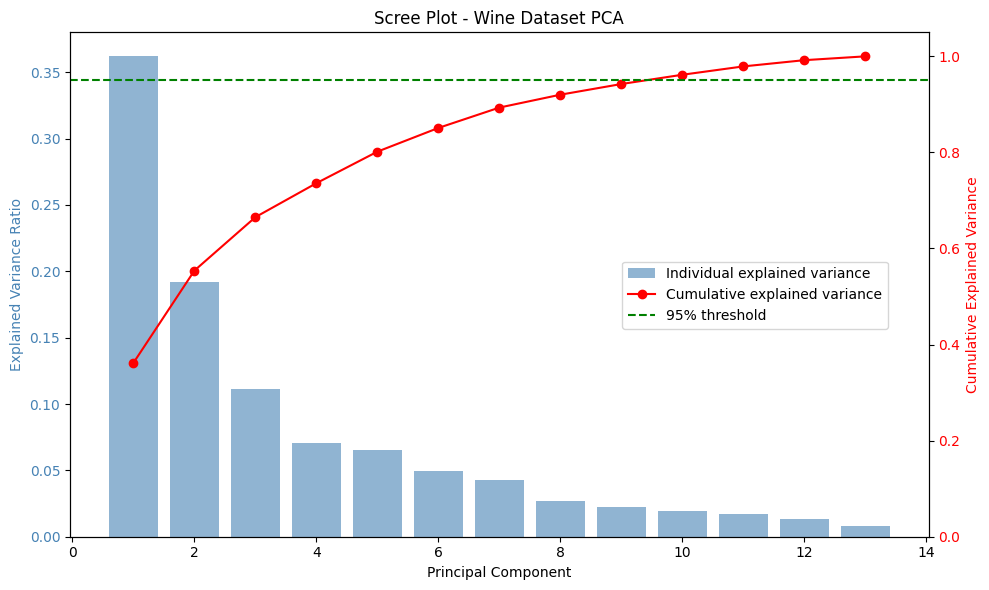


Number of components needed to explain >=95% variance: 10
(Out of 13 original features)

This means we could reduce from 13 dimensions to
10 dimensions while keeping 95% of the information.


In [12]:
cumulative_var = np.cumsum(variance_ratio)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(range(1, len(variance_ratio) + 1), variance_ratio,
        alpha=0.6, color="steelblue", label="Individual explained variance")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_var) + 1), cumulative_var,
         color="red", marker="o", label="Cumulative explained variance")
ax2.axhline(0.95, color="green", linestyle="--", label="95% threshold")
ax2.set_ylabel("Cumulative Explained Variance", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.set_ylim(0, 1.05)
 
plt.title("Scree Plot - Wine Dataset PCA")
fig.legend(loc="center right", bbox_to_anchor=(0.9, 0.5))
plt.tight_layout()
plt.show()

# How many components for 95% variance?
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\nNumber of components needed to explain >=95% variance: {n_components_95}")
print(f"(Out of {X_wine_scaled.shape[1]} original features)")
print(f"\nThis means we could reduce from {X_wine_scaled.shape[1]} dimensions to")
print(f"{n_components_95} dimensions while keeping 95% of the information.")

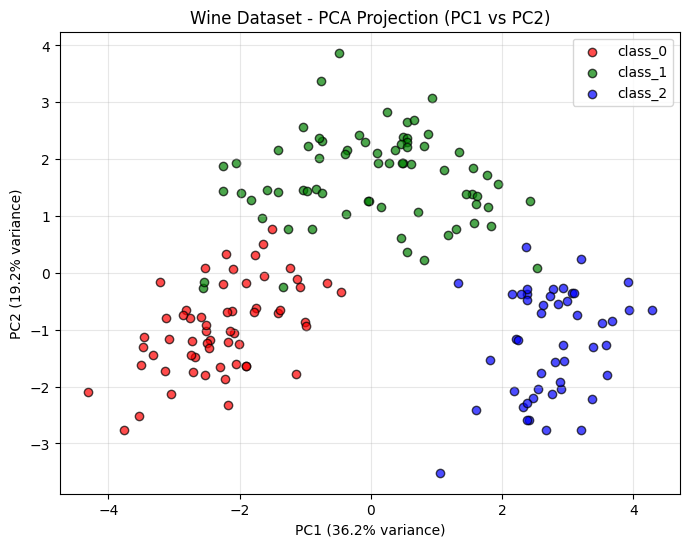

Notice: PCA did NOT use the class labels (y_wine) at all - it only
looked at X. Yet the 3 classes still separate reasonably well. This
is a 'happy accident' - it means the directions of MAXIMUM VARIANCE
happen to ALSO be directions that separate the classes. This is NOT
guaranteed in general - that's exactly the gap LDA is designed to fill.


In [13]:
plt.figure(figsize=(8, 6))
colors = ["red", "green", "blue"]
for class_idx, class_name in enumerate(wine.target_names):
    mask = Y_wine == class_idx
    plt.scatter(X_projected[mask, 0], X_projected[mask, 1],
                c=colors[class_idx], label=class_name, alpha=0.7, edgecolor="k")
 
plt.xlabel(f"PC1 ({variance_ratio[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({variance_ratio[1]*100:.1f}% variance)")
plt.title("Wine Dataset - PCA Projection (PC1 vs PC2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
 
print("Notice: PCA did NOT use the class labels (y_wine) at all - it only")
print("looked at X. Yet the 3 classes still separate reasonably well. This")
print("is a 'happy accident' - it means the directions of MAXIMUM VARIANCE")
print("happen to ALSO be directions that separate the classes. This is NOT")
print("guaranteed in general - that's exactly the gap LDA is designed to fill.")

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
X_train , X_test , Y_train , Y_test = train_test_split(X_wine_scaled,Y_wine,test_size=0.3,random_state=42)
model = LogisticRegression(max_iter=1000)

classification = model.fit(X_train,Y_train)
y_pred = classification.predict(X_test)
acc_raw = accuracy_score(y_pred=y_pred,y_true=Y_test)
acc_raw

0.9814814814814815

In [15]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)
classification_2 = model.fit(X_train_pca,Y_train)
y_pred = classification_2.predict(X_test_pca)
acc_pca = accuracy_score(y_pred=y_pred,y_true=Y_test)
acc_pca

0.9444444444444444

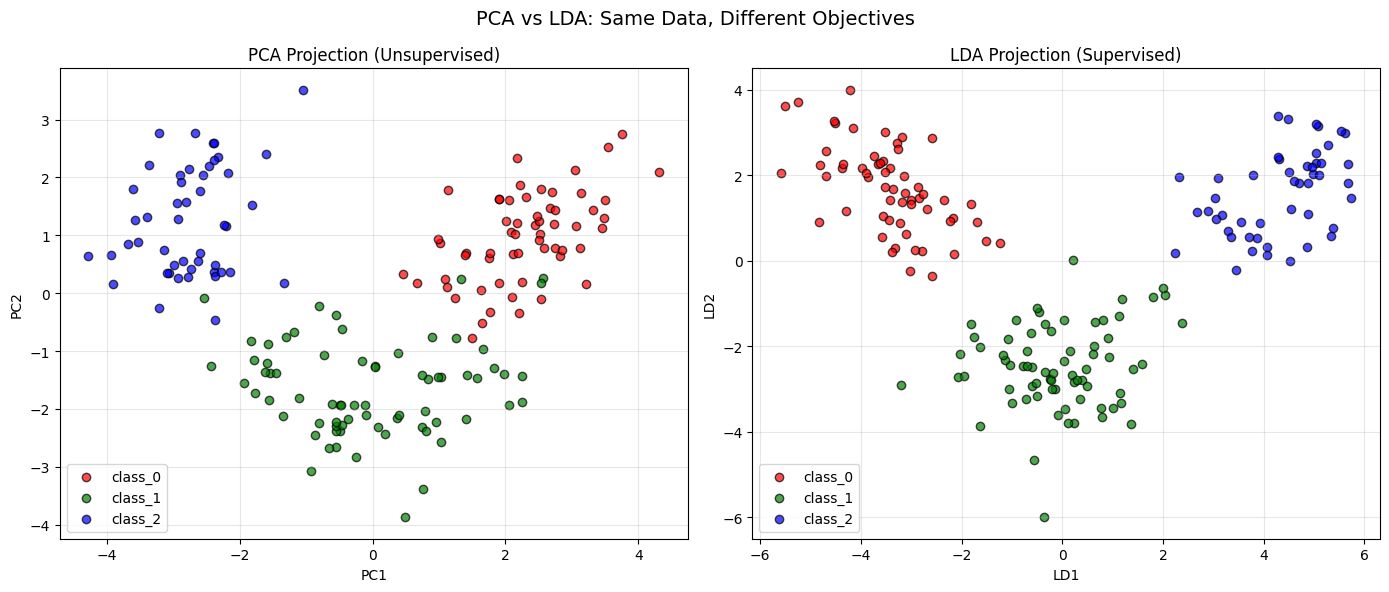

Look at the LDA plot (right) - the 3 classes should form TIGHTER,
MORE CLEARLY SEPARATED clusters compared to PCA (left). This is
BY DESIGN - LDA explicitly optimizes for class separation, while
PCA optimizes for variance and got lucky that it correlated with
class separation.


In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X_wine_scaled, Y_wine)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Left: PCA projection (unsupervised)
for class_idx, class_name in enumerate(wine.target_names):
    mask = Y_wine == class_idx
    axes[0].scatter(X_pca_sklearn[mask, 0], X_pca_sklearn[mask, 1],
                    c=colors[class_idx], label=class_name, alpha=0.7, edgecolor="k")
axes[0].set_title("PCA Projection (Unsupervised)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for class_idx, class_name in enumerate(wine.target_names):
    mask = Y_wine == class_idx
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1],
                    c=colors[class_idx], label=class_name, alpha=0.7, edgecolor="k")
axes[1].set_title("LDA Projection (Supervised)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.suptitle("PCA vs LDA: Same Data, Different Objectives", fontsize=14)
plt.tight_layout()
plt.show()
 
print("Look at the LDA plot (right) - the 3 classes should form TIGHTER,")
print("MORE CLEARLY SEPARATED clusters compared to PCA (left). This is")
print("BY DESIGN - LDA explicitly optimizes for class separation, while")
print("PCA optimizes for variance and got lucky that it correlated with")
print("class separation.")

In [17]:
lda_2 = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda_2.fit_transform(X_train, Y_train)
X_test_lda = lda_2.transform(X_test)
 
clf_lda = LogisticRegression(max_iter=1000, random_state=42)
clf_lda.fit(X_train_lda, Y_train)
acc_lda = accuracy_score(Y_test, clf_lda.predict(X_test_lda))
 
print("Accuracy comparison (all using 2 dimensions, except raw):")
print(f"  Raw (13 dims):        {acc_raw:.4f}")
print(f"  PCA  (2 dims):        {acc_pca:.4f}")
print(f"  LDA  (2 dims):        {acc_lda:.4f}")
print("\nLDA typically performs AT LEAST as well as PCA here (often better)")
print("for classification specifically, BECAUSE it was designed with class")
print("separability as its explicit objective - PCA was not.")

Accuracy comparison (all using 2 dimensions, except raw):
  Raw (13 dims):        0.9815
  PCA  (2 dims):        0.9444
  LDA  (2 dims):        0.9815

LDA typically performs AT LEAST as well as PCA here (often better)
for classification specifically, BECAUSE it was designed with class
separability as its explicit objective - PCA was not.


In [18]:
digits = load_digits()
# Pick one digit image - shape (8, 8) = 64 pixels
image = digits.images[8]  # an example digit
 
print("Original image shape:", image.shape)
print("Original image (pixel intensity matrix):")
print(image.astype(int))

Original image shape: (8, 8)
Original image (pixel intensity matrix):
[[ 0  0  9 14  8  1  0  0]
 [ 0  0 12 14 14 12  0  0]
 [ 0  0  9 10  0 15  4  0]
 [ 0  0  3 16 12 14  2  0]
 [ 0  0  4 16 16  2  0  0]
 [ 0  3 16  8 10 13  2  0]
 [ 0  1 15  1  3 16  8  0]
 [ 0  0 11 16 15 11  1  0]]


In [19]:
U, S, Vt = np.linalg.svd(image, full_matrices=False)
print(f"\nU shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S.round(2)}")


U shape: (8, 8), S shape: (8,), Vt shape: (8, 8)
Singular values: [60.85 23.75 11.21  7.49  3.96  1.85  0.    0.  ]


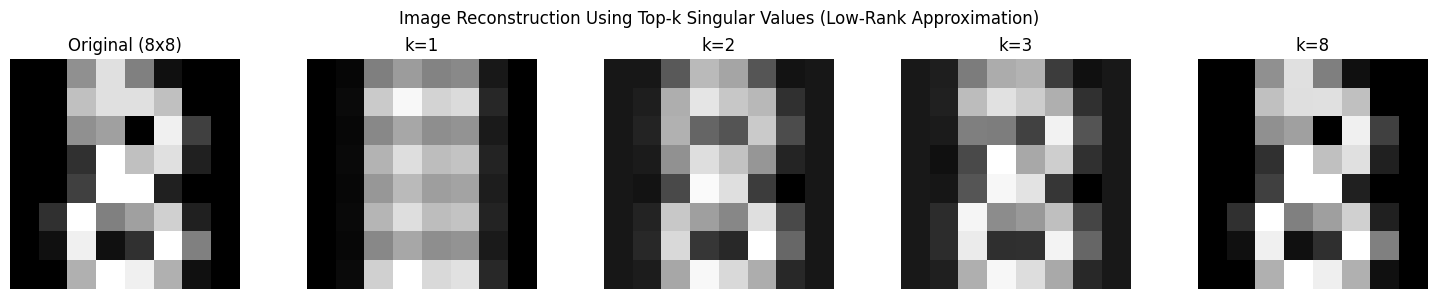


Cumulative energy captured by top-k singular values:
  k=1: 82.88%
  k=2: 95.50%
  k=3: 98.32%
  k=8: 100.00%

Notice: with just k=3 (out of 8 possible), we already capture most
of the image's structure. This is EXACTLY the same idea as PCA's
explained variance ratio - just applied directly to an image matrix
instead of a dataset's covariance matrix.


In [20]:
def reconstruct_image(U, S, Vt, k):
    """
    Reconstruct an image using only the TOP-k singular values.
    This is the LOW-RANK APPROXIMATION: A_k = U[:,:k] @ diag(S[:k]) @ Vt[:k,:]
    """
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
 
 
# Reconstruct using different numbers of singular values
k_values = [1, 2, 3, 8]
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(15, 3))
 
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original (8x8)")
axes[0].axis("off")
 
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(U, S, Vt, k)
    axes[i + 1].imshow(reconstructed, cmap="gray")
    axes[i + 1].set_title(f"k={k}")
    axes[i + 1].axis("off")
 
plt.suptitle("Image Reconstruction Using Top-k Singular Values (Low-Rank Approximation)")
plt.tight_layout()
plt.show()
 
# How much "energy" (variance) does each k capture?
energy = (S ** 2) / np.sum(S ** 2)
cumulative_energy = np.cumsum(energy)
print("\nCumulative energy captured by top-k singular values:")
for k in k_values:
    print(f"  k={k}: {cumulative_energy[k-1]*100:.2f}%")
 
print("\nNotice: with just k=3 (out of 8 possible), we already capture most")
print("of the image's structure. This is EXACTLY the same idea as PCA's")
print("explained variance ratio - just applied directly to an image matrix")
print("instead of a dataset's covariance matrix.")

In [21]:
ratings = np.array([
    [5, 4, 0, 1, 0, 1],
    [4, 5, 0, 1, 0, 0],
    [1, 1, 0, 5, 5, 4],
    [1, 0, 1, 4, 4, 5],
    [0, 1, 5, 4, 0, 4],
    [2, 1, 4, 5, 0, 5],
], dtype=float)

In [22]:
print("Original ratings matrix (0 = not yet rated):")
print(pd.DataFrame(ratings, columns=[f"Movie{i}" for i in range(6)],
                    index=[f"User{i}" for i in range(6)]))

Original ratings matrix (0 = not yet rated):
       Movie0  Movie1  Movie2  Movie3  Movie4  Movie5
User0     5.0     4.0     0.0     1.0     0.0     1.0
User1     4.0     5.0     0.0     1.0     0.0     0.0
User2     1.0     1.0     0.0     5.0     5.0     4.0
User3     1.0     0.0     1.0     4.0     4.0     5.0
User4     0.0     1.0     5.0     4.0     0.0     4.0
User5     2.0     1.0     4.0     5.0     0.0     5.0


In [23]:
user_means = np.true_divide(ratings.sum(axis=1), (ratings != 0).sum(axis=1))
ratings_centered = ratings - user_means.reshape(-1, 1)
ratings_centered[ratings == 0] = 0  # keep missing entries as 0 for SVD input
 
print("\nUser means (avg of their NON-ZERO ratings):", user_means.round(2))


User means (avg of their NON-ZERO ratings): [2.75 3.33 3.2  3.   3.5  3.4 ]


In [24]:
U, S, Vt = np.linalg.svd(ratings_centered, full_matrices=False)


In [25]:
k = 2  # assume 2 hidden "taste dimensions" explain most preferences
predicted_centered = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
 
# Add back the user means to get predicted ratings on the original scale
predicted_ratings = predicted_centered + user_means.reshape(-1, 1)

In [26]:
print(f"\nPredicted ratings matrix (using top {k} latent factors):")
print(pd.DataFrame(predicted_ratings.round(2), columns=[f"Movie{i}" for i in range(6)],
                    index=[f"User{i}" for i in range(6)]))


Predicted ratings matrix (using top 2 latent factors):
       Movie0  Movie1  Movie2  Movie3  Movie4  Movie5
User0    4.68    4.31    3.11    1.03    2.05    1.31
User1    4.31    5.12    2.83    2.06    3.06    2.62
User2    1.19    1.11    3.14    5.18    3.89    4.69
User3    0.74    3.20    1.18    4.18    3.99    4.71
User4    3.39    1.21    4.98    4.50    3.36    3.55
User5    1.94    1.01    3.95    5.19    3.84    4.47


In [ ]:
print("\nFor entries that were originally 0 (unrated), the predicted value")
print("is SVD's GUESS at what that user would rate that movie - based on")
print("patterns learned from users with SIMILAR rating behavior. This is")
print("the foundation of collaborative filtering recommendation systems.")